In [ ]:
!pip install ~/FRB

Processing /arc/home/calvin/FRB
  Preparing metadata (setup.py) ... done
  Created wheel for FRB: filename=FRB-0.1.dev0-py3-none-any.whl size=19511232 sha256=1aab2607efb76a82d2586d57f803c1aae5e6678f0d009601d29aa666420a01f8
  Stored in directory: /tmp/pip-ephem-wheel-cache-fau0brar/wheels/2f/19/45/9a2813d45af11781e9f971215f78a488d0c3f329071884b5e4
Successfully built FRB


In [1]:
from frb.surveys.decals import DECaL_Survey


In [64]:
files = glob.glob('/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/FRB2023*/*_candidates.csv')

threshold_pox = 0.9
for f in files:
    cands = pd.read_csv(f)
    gold_host_cands = (cands['P_Ox'].values > threshold_pox)
    cands = cands.iloc[gold_host_cands]
    cands.set_index('ID',inplace = True)
    #print(f)
    if len(cands) == 0:
        pass#print('No association')
    elif len(cands) > 0:
        for survey_id in cands.index:
            cand = cands.loc[survey_id]
            sc = coord.SkyCoord(ra = cand['ra'],dec = cand['dec'], unit="deg")
            radius = 1*u.arcmin
            if cand['survey'] == 'Pan-STARRS':
                survey = Pan_STARRS_Survey(sc, radius)
                catalog = survey.get_catalog()
                catalog = catalog[catalog['Pan-STARRS_ID']==survey_id]
            elif cand['survey'] == 'DECaLS':
                survey = DECaL_Survey(sc, radius)
                catalog = survey.get_catalog()
                catalog = catalog[catalog['DECaLS_ID']==survey_id]
            #query_answer = Simbad.query_region(sc, radius='0d1m0s')

    
        #print(cands)
        if survey_id in photo_z_dict.keys():
            if 'PS1_STRM_WISE' in photo_z_dict[survey_id]:
                photo_z,photo_z_err = photo_z_dict[survey_id]['PS1_STRM_WISE']
                photo_z_type = 'PS1_STRM_WISE'
            elif 'PS1_STRM' in photo_z_dict[survey_id]:
                photo_z,photo_z_err = photo_z_dict[survey_id]['PS1_STRM']
                photo_z_type = 'PS1_STRM'
        else:
            photo_z = -1
            photo_z_err = -1
        print(f)
        print('ID:',survey_id,'ra',cand['ra'],'dec',cand['dec'],'r=',catalog['rPSFmag'][0],'zphot=',photo_z,'+-',photo_z_err,photo_z_type)
        casjobs_string = f"""
        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
        from catalogRecordRowStore as o
        inner join fGetNearbyObjEq({cand['ra']}, {cand['dec']}, 20.0/60.0) as nb
        on o.objid=nb.objid and o.objID={survey_id}
        """
        print(casjobs_string)
        #print(query_answer)

/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/FRB20231011A/FRB20231011A_PATH_candidates.csv
ID: 158090182417819186 ra 18.24170617 dec 41.74899511 r= 20.101699829101562 zphot= 0.07240619 +- 0.0118954230702462 PS1_STRM_WISE

        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
        from catalogRecordRowStore as o
        inner join fGetNearbyObjEq(18.24170617, 41.74899511, 20.0/60.0) as nb
        on o.objid=nb.objid and o.objID=158090182417819186
        
/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/FRB20231008A/FRB20231008A_PATH_candidates.csv
ID: 166443472702098523 ra 347.27023884 dec 48.70658382 r= 20.44969940185547 zphot= 0.17119311 +- 0.0463336810818657 PS1_STRM_WISE

        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
        from catalogRecordRowStore as o
        inner join fGetNearbyObjEq(347.27023884, 48.70658382, 20.0/60.0) as nb
        on o.objid=nb.objid and o.objID=16644347270

In [11]:
import pandas as pd

In [3]:
from astropy.coordinates import SkyCoord
import astropy.units as u

In [63]:
final = pd.read_csv('/arc/home/calvin/kko_host_paper/data_products/kko_full_cat.csv',
names = ['chime_event_id','name', 'ra_frb', 'dec_frb', 'b_err', 'a_err', 'gal_b', 'gal_l',
       'DM_YT20', 'DM_NE2001', 'theta', 'tags', 'frb_survey', 'DM', 'include',
       'locnote', 'hgnote', 'desi_cutout', 'tau_NE2001_600',
       'primary_z_spec_source', 'primary_id', 'primary_ra', 'primary_dec',
       'primary_P_Ox', 'primary_z_phot_median', 'primary_z_phot_l95',
       'primary_z_phot_u95', 'primary_z_spec', 'primary_mag', 'secondary_id','secondary_ra',
       'secondary_dec', 'secondary_P_Ox', 'secondary_z_phot_median',
       'secondary_z_phot_l95', 'secondary_z_phot_u95', 'secondary_z_spec',
       'secondary_mag', 'flux', 'flux_err', 'fluence', 'fluence_err',
       'dm_igm'],
    skiprows=1)
final.set_index('chime_event_id',inplace=True)
final = final[final['include'] == 'yes']

In [15]:
import requests

# Add DR9 photo-z

In [66]:
for evid,row in final.iterrows():
    for cand in ['primary','secondary']:
        if type(row[f'{cand}_id']) is str:
            if row[f'{cand}_id'][0:3] == 'DEC':
                ra = row[f'{cand}_ra']
                dec=row[f'{cand}_dec']
                ralo = row[f'{cand}_ra'] - 1/3600
                rahi = row[f'{cand}_ra'] + 1/3600
                declo= row[f'{cand}_dec'] - 1/3600
                dechi= row[f'{cand}_dec'] + 1/3600
                req_str = f"https://www.legacysurvey.org/viewer/photoz-dr9/1/cat.json?ralo={ralo:.4f}&rahi={rahi:.4f}&declo={declo:.4f}&dechi={dechi:.4f}"
                response = requests.get(req_str)
                data = response.json()
                if len(data['rd']) > 0:
                    print(f'{evid} offset:',(data['rd'][0][0] - ra) * 3600,'offset:',(data['rd'][0][1] - dec) * 3600,'z=',data['phot_z_mean'][0])
                if len(data['rd']) > 1:
                    print(f'{evid} multiple matches for {evid}; photoz are {data["phot_z_mean"]}')
                if len(data['rd']) == 1:
                    final.at[evid,f"{cand}_z_phot_median"] = data["phot_z_mean"][0]
                    final.at[evid,f"{cand}_z_phot_l95"] = max(data["phot_z_mean"][0] - 2 * data["phot_z_std"][0],0)
                    final.at[evid,f"{cand}_z_phot_u95"] = max(data["phot_z_mean"][0] + 2 * data["phot_z_std"][0],0)
        else:
            print(f"No path for {evid}")

335002503 offset: 2.0463630789890885e-10 offset: 1.5347723092418164e-10 z= 0.6514573693275452
No path for 335002503
No path for 348570237
325140573 offset: 6.139089236967266e-10 offset: 2.3021584638627246e-10 z= 0.10421065241098404
No path for 325140573
331641308 offset: 2.4556356947869062e-09 offset: 3.069544618483633e-10 z= 0.311547189950943
No path for 331641308
326033351 offset: 0.00033078773640227155 offset: 3.185148784723424e-05 z= 0.5638987421989441
No path for 326033351
347265274 offset: 6.139089236967266e-10 offset: 3.069544618483633e-10 z= 0.2522886097431183
No path for 347265274
No path for 308358106
342256558 offset: 2.660272002685815e-09 offset: 2.5579538487363607e-10 z= 0.04899613931775093
No path for 342256558
341979347 offset: 1.944044925039634e-09 offset: 1.7905676941154525e-10 z= 0.3500325381755829
No path for 341979347
344693725 offset: 0.0012018463280583092 offset: -0.020185018792417964 z= 0.051623471081256866
No path for 344693725
324962446 offset: -0.0007517746553

In [3]:
import numpy as np

import pandas as pd

from frb.surveys.panstarrs import Pan_STARRS_Survey
from frb.surveys.decals import DECaL_Survey
from astropy.coordinates import SkyCoord
from astropy import units as u


import glob

import astroquery

from astroquery.simbad import Simbad

import astropy.units as u

import astropy.coordinates as coord

In [2]:
photo_z_dict = {
 158090182417819186: {'PS1_STRM': [0.08914095,0.0175031167179699],
                        'PS1_STRM_WISE' : [0.07240619,0.0118954230702462],},
 166443472702098523: {'PS1_STRM' : [0.1387384, 0.0948375836611045],
                        'PS1_STRM_WISE' : [0.17119311,0.0463336810818657],},
 147790546649113381 : {'PS1_STRM' : [0.3192104, 0.162667679515143]},
 175130911105314689 : {'PS1_STRM' : [0.16301307,0.0485150064380436],
                       'PS1_STRM_WISE' : [0.216579, 0.0205760454376182],},
 
 140170545876545920 : {'PS1_STRM' : [0.09083903,0.0303555731615571],
                       'PS1_STRM_WISE' : [0.17583069,0.0186939412537729]},
 113360826227259720 : {'PS1_STRM' : [0.07495457,0.0132193777203354],
                       'PS1_STRM_WISE' : [0.06860938,0.00888159718073157]},
    
 121461069605007945 : {'PS1_STRM_WISE' : [0.085439004,0.0340526632051041]},
 147790546649113381 : {'PS1_STRM' : [ 0.3192104, 0.162667679515143]},
                      }

In [64]:
for f in files:
    cands = pd.read_csv(f)
    gold_host_cands = (cands['P_Ox'].values > threshold_pox)
    cands = cands.iloc[gold_host_cands]
    cands.set_index('ID',inplace = True)
    #print(f)
    if len(cands) == 0:
        pass#print('No association')
    elif len(cands) > 0:
        for survey_id in cands.index:
            cand = cands.loc[survey_id]
            sc = coord.SkyCoord(ra = cand['ra'],dec = cand['dec'], unit="deg")
            radius = 1*u.arcmin
            if cand['survey'] == 'Pan-STARRS':
                survey = Pan_STARRS_Survey(sc, radius)
                catalog = survey.get_catalog()
                catalog = catalog[catalog['Pan-STARRS_ID']==survey_id]
            elif cand['survey'] == 'DECaLS':
                survey = DECaL_Survey(sc, radius)
                catalog = survey.get_catalog()
                catalog = catalog[catalog['DECaLS_ID']==survey_id]
            #query_answer = Simbad.query_region(sc, radius='0d1m0s')

    
        #print(cands)
        if survey_id in photo_z_dict.keys():
            if 'PS1_STRM_WISE' in photo_z_dict[survey_id]:
                photo_z,photo_z_err = photo_z_dict[survey_id]['PS1_STRM_WISE']
                photo_z_type = 'PS1_STRM_WISE'
            elif 'PS1_STRM' in photo_z_dict[survey_id]:
                photo_z,photo_z_err = photo_z_dict[survey_id]['PS1_STRM']
                photo_z_type = 'PS1_STRM'
        else:
            photo_z = -1
            photo_z_err = -1
        print(f)
        print('ID:',survey_id,'ra',cand['ra'],'dec',cand['dec'],'r=',catalog['rPSFmag'][0],'zphot=',photo_z,'+-',photo_z_err,photo_z_type)
        casjobs_string = f"""
        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
        from catalogRecordRowStore as o
        inner join fGetNearbyObjEq({cand['ra']}, {cand['dec']}, 20.0/60.0) as nb
        on o.objid=nb.objid and o.objID={survey_id}
        """
        print(casjobs_string)
        #print(query_answer)

/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/FRB20231011A/FRB20231011A_PATH_candidates.csv
ID: 158090182417819186 ra 18.24170617 dec 41.74899511 r= 20.101699829101562 zphot= 0.07240619 +- 0.0118954230702462 PS1_STRM_WISE

        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
        from catalogRecordRowStore as o
        inner join fGetNearbyObjEq(18.24170617, 41.74899511, 20.0/60.0) as nb
        on o.objid=nb.objid and o.objID=158090182417819186
        
/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/FRB20231008A/FRB20231008A_PATH_candidates.csv
ID: 166443472702098523 ra 347.27023884 dec 48.70658382 r= 20.44969940185547 zphot= 0.17119311 +- 0.0463336810818657 PS1_STRM_WISE

        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
        from catalogRecordRowStore as o
        inner join fGetNearbyObjEq(347.27023884, 48.70658382, 20.0/60.0) as nb
        on o.objid=nb.objid and o.objID=16644347270

In [ ]:
https://www.legacysurvey.org/viewer/photoz-dr9/1/cat.json?ralo=183.1147&rahi=183.1487&declo=12.1365&dechi=12.15514

In [2]:
from frb.surveys.decals import DECaL_Survey


In [55]:
from frb.surveys.decals import DECaL_Survey
a  = pandas.read_csv('/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/chime_frb_redshifts.csv')

for file in ['/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_bright_first10.csv',
             '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_bright_first10.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_bright_jan_05.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_kko_feb2024.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_kko_nov2023.csv',
            '/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/FRBs/chime_kko_sep2023.csv']:
    b = pandas.read_csv(file)
    print(b)

import numpy as np

import pandas as pd
import pandas
from frb.surveys.panstarrs import Pan_STARRS_Survey
from frb.surveys.decals import DECaL_Survey
from astropy.coordinates import SkyCoord
from astropy import units as u


import glob

import astroquery

from astroquery.simbad import Simbad

import astropy.units as u

import astropy.coordinates as coord

photo_z_dict = {
 158090182417819186: {'PS1_STRM': [0.08914095,0.0175031167179699],
                        'PS1_STRM_WISE' : [0.07240619,0.0118954230702462],},
 166443472702098523: {'PS1_STRM' : [0.1387384, 0.0948375836611045],
                        'PS1_STRM_WISE' : [0.17119311,0.0463336810818657],},
 147790546649113381 : {'PS1_STRM' : [0.3192104, 0.162667679515143]},
 175130911105314689 : {'PS1_STRM' : [0.16301307,0.0485150064380436],
                       'PS1_STRM_WISE' : [0.216579, 0.0205760454376182],},
 
 140170545876545920 : {'PS1_STRM' : [0.09083903,0.0303555731615571],
                       'PS1_STRM_WISE' : [0.17583069,0.0186939412537729]},
 113360826227259720 : {'PS1_STRM' : [0.07495457,0.0132193777203354],
                       'PS1_STRM_WISE' : [0.06860938,0.00888159718073157]},
    
 121461069605007945 : {'PS1_STRM_WISE' : [0.085439004,0.0340526632051041]},
 147790546649113381 : {'PS1_STRM' : [ 0.3192104, 0.162667679515143]},
                      }

files = glob.glob('/arc/home/calvin/chime-ffff-pz/chime_ffff_pz/data/PATH/FRB2023*/*_candidates.csv')
threshold_pox = 0.9
for f in files:
    cands = pd.read_csv(f)
    gold_host_cands = (cands['P_Ox'].values > threshold_pox)
    cands = cands.iloc[gold_host_cands]
    cands.set_index('ID',inplace = True)
    #print(f)
    if len(cands) == 0:
        pass#print('No association')
    elif len(cands) > 0:
        for survey_id in cands.index:
            cand = cands.loc[survey_id]
            sc = coord.SkyCoord(ra = cand['ra'],dec = cand['dec'], unit="deg")
            radius = 1*u.arcmin
            if cand['survey'] == 'Pan-STARRS':
                survey = Pan_STARRS_Survey(sc, radius)
                catalog = survey.get_catalog()
                catalog = catalog[catalog['Pan-STARRS_ID']==survey_id]
            elif cand['survey'] == 'DECaLS':
                survey = DECaL_Survey(sc, radius)
                catalog = survey.get_catalog()
                catalog = catalog[catalog['DECaLS_ID']==survey_id]
            #query_answer = Simbad.query_region(sc, radius='0d1m0s')

    
        #print(cands)
        if survey_id in photo_z_dict.keys():
            if 'PS1_STRM_WISE' in photo_z_dict[survey_id]:
                photo_z,photo_z_err = photo_z_dict[survey_id]['PS1_STRM_WISE']
                photo_z_type = 'PS1_STRM_WISE'
            elif 'PS1_STRM' in photo_z_dict[survey_id]:
                photo_z,photo_z_err = photo_z_dict[survey_id]['PS1_STRM']
                photo_z_type = 'PS1_STRM'
        else:
            photo_z = -1
            photo_z_err = -1
        print(f)
        print('ID:',survey_id,'ra',cand['ra'],'dec',cand['dec'],'r=',catalog['rPSFmag'][0],'zphot=',photo_z,'+-',photo_z_err,photo_z_type)
        casjobs_string = f"""
        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
        from catalogRecordRowStore as o
        inner join fGetNearbyObjEq({cand['ra']}, {cand['dec']}, 20.0/60.0) as nb
        on o.objid=nb.objid and o.objID={survey_id}
        """
        print(casjobs_string)
        #print(query_answer)

  frb_survey          tags          name  ra_err  dec_err     DM     a_err   
0  CHIME/FRB  CHIME-Bright  FRB20190125B      20       30  177.9  0.008333  \
1  CHIME/FRB  CHIME-Bright  FRB20190202B      44       52  464.8  0.014444   
2  CHIME/FRB  CHIME-Bright  FRB20190210D      25       42  359.3  0.011667   
3  CHIME/FRB  CHIME-Bright  FRB20191104B      56       63  192.2  0.017500   
4  CHIME/FRB  CHIME-Bright  FRB20191202A     136      415  117.9  0.115278   
5  CHIME/FRB  CHIME-Bright  FRB20191219E      45       80  736.7  0.022222   
6  CHIME/FRB  CHIME-Bright  FRB20201105A      57       58  262.4  0.016111   
7  CHIME/FRB  CHIME-Bright  FRB20201129A      29       48  274.6  0.013333   
8  CHIME/FRB  CHIME-Bright  FRB20210310B      32       39  135.5  0.010833   
9  CHIME/FRB  CHIME-Bright  FRB20210810A      17       20  246.9  0.005556   

      b_err  theta          ra        dec  
0  0.005556      0  217.450120  49.631878  
1  0.012222      0  105.580029  31.958580  
2  0.0069


KeyboardInterrupt



In [58]:
final.keys()

Index(['name', 'ra_frb', 'dec_frb', 'b_err', 'a_err', 'gal_b', 'gal_l',
       'DM_YT20', 'DM_NE2001', 'theta', 'tags', 'frb_survey', 'DM', 'include',
       'locnote', 'hgnote', 'desi_cutout', 'tau_NE2001_600',
       'primary_z_spec_source', 'primary_id', 'primary_ra', 'primary_dec',
       'primary_P_Ox', 'primary_z_phot_median', 'primary_z_phot_l95',
       'primary_z_phot_u95', 'primary_z_spec', 'primary_mag', 'secondary_ra',
       'secondary_dec', 'secondary_P_Ox', 'secondary_z_phot_median',
       'secondary_z_phot_l95', 'secondary_z_phot_u95', 'secondary_z_spec',
       'secondary_mag', 'flux', 'flux_err', 'fluence', 'fluence_err',
       'dm_igm'],
      dtype='object')

In [62]:
final['primary_id']

Series([], Name: primary_id, dtype: float64)

In [69]:
row['primary_id']

'DECaL 9907742453860745'

In [71]:
for evid,row in final.iterrows():
    for cand in ['primary','secondary']:
        if type(row[f'{cand}_id']) is str:
            if row[f'{cand}_id'][0:3] == 'Pan':
                ra = row[f"{cand}_ra"]
                dec= row[f"{cand}_dec"]
                _,survey_id = row[f"{cand}_id"].split(' ')
                casjobs_string = f"""
                        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
                        from catalogRecordRowStore as o
                        inner join fGetNearbyObjEq({ra}, {dec}, 20.0/60.0) as nb
                        on o.objid=nb.objid and o.objID={survey_id}
                        """
                print(casjobs_string)
            


                        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
                        from catalogRecordRowStore as o
                        inner join fGetNearbyObjEq(355.77402784, 78.09258301, 20.0/60.0) as nb
                        on o.objid=nb.objid and o.objID=201713557741821895
                        

                        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
                        from catalogRecordRowStore as o
                        inner join fGetNearbyObjEq(36.01389362, 52.68584749, 20.0/60.0) as nb
                        on o.objid=nb.objid and o.objID=171220360141353770
                        

                        select o.objID, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class
                        from catalogRecordRowStore as o
                        inner join fGetNearbyObjEq(26.46776439, 35.10782949, 20.0/60.0) as nb
                        on o

# Let's try the PanSTARRS DR1 photo-z catalog
https://academic.oup.com/mnras/article/500/2/1633/5899759#214799955

In [5]:
photo_z_dict = {
 158090182417819186: {'PS1_STRM': [0.08914095,0.0175031167179699],
                        'PS1_STRM_WISE' : [0.07240619,0.0118954230702462],},
 166443472702098523: {'PS1_STRM' : [0.1387384, 0.0948375836611045],
                        'PS1_STRM_WISE' : [0.17119311,0.0463336810818657],},
 147790546649113381 : {'PS1_STRM' : [0.3192104, 0.162667679515143]},
 175130911105314689 : {'PS1_STRM' : [0.16301307,0.0485150064380436],
                       'PS1_STRM_WISE' : [0.216579, 0.0205760454376182],},
 
 140170545876545920 : {'PS1_STRM' : [0.09083903,0.0303555731615571],
                       'PS1_STRM_WISE' : [0.17583069,0.0186939412537729]},
 113360826227259720 : {'PS1_STRM' : [0.07495457,0.0132193777203354],
                       'PS1_STRM_WISE' : [0.06860938,0.00888159718073157]},
    
 121461069605007945 : {'PS1_STRM_WISE' : [0.085439004,0.0340526632051041]},
 147790546649113381 : {'PS1_STRM' : [ 0.3192104, 0.162667679515143]},
                      }

```
objID	            z_phot              z_photErr           z_phot0	    extrapolation_Photoz	class
158090182417819186	0.0889956504106522	0.0175031167179699	0.08914095	0	GALAXY
158090182417819186	0.0720998011529446	0.0118954230702462	0.07240619	0	GALAXY # Using WISE + PanSTARRS

166443472702098523	0.159047991037369	0.0948375836611045	0.1387384	0	GALAXY
166443472702098523	0.193797573447227	0.0463336810818657	0.17119311	0	GALAXY # Using WISE + PanSTARRS

147790546649113381	0.303392082452774	0.162667679515143	0.3192104	0	GALAXY

154360650307570235	-999	-999	-999	-999	UNSURE

175130911105314689	0.168087460100651	0.0485150064380436	0.16301307	0	GALAXY
175130911105314689	0.210095427930355	0.0205760454376182	0.216579	0	GALAXY # Using WISE + PanSTARRS

140170545876545920	0.0980126708745956	0.0303555731615571	0.09083903	0	GALAXY
140170545876545920	0.168767355382442	0.0186939412537729	0.17583069	0	GALAXY # Using WISE + PanSTARRS

113360826227259720	0.0755622088909149	0.0132193777203354	0.07495457	0	GALAXY
113360826227259720	0.068134531378746	0.00888159718073157	0.06860938	0	GALAXY # Using WISE + PanSTARRS

121461069605007945	1005164000028539	-999	-999	-999	-999	UNSURE
121461069605007945	0.0854664817452431	0.0340526632051041	0.085439004	0	GALAXY # Used WISE PS1 Photo-z

147790546649113381	0.303392082452774	0.162667679515143	0.3192104	0	GALAXY
```

# CasJobs
```
select o.objID, o.uniquePspsOBid, o.z_phot, o.z_photErr, o.z_phot0, o.extrapolation_Photoz, o.class 
from catalogRecordRowStore as o
inner join fGetNearbyObjEq(18.24170617, 41.74899511, 20.0/60.0) as nb
on o.objid=nb.objid and o.objID=158090182417819186
```

# This is garbage
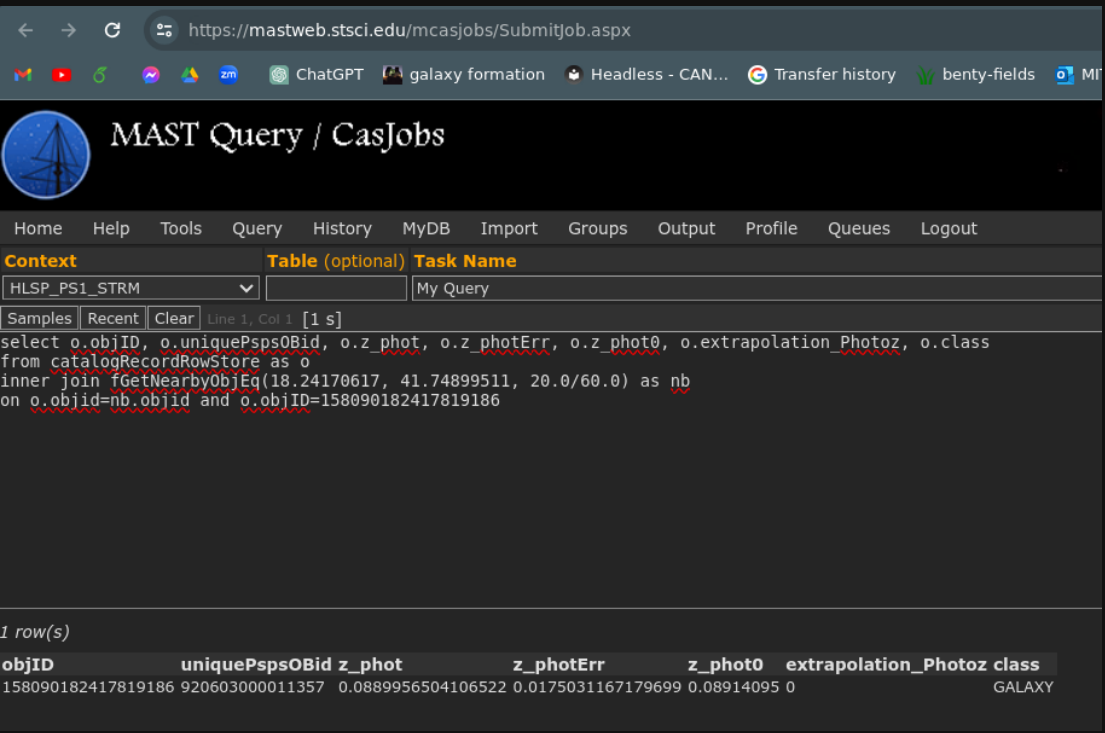

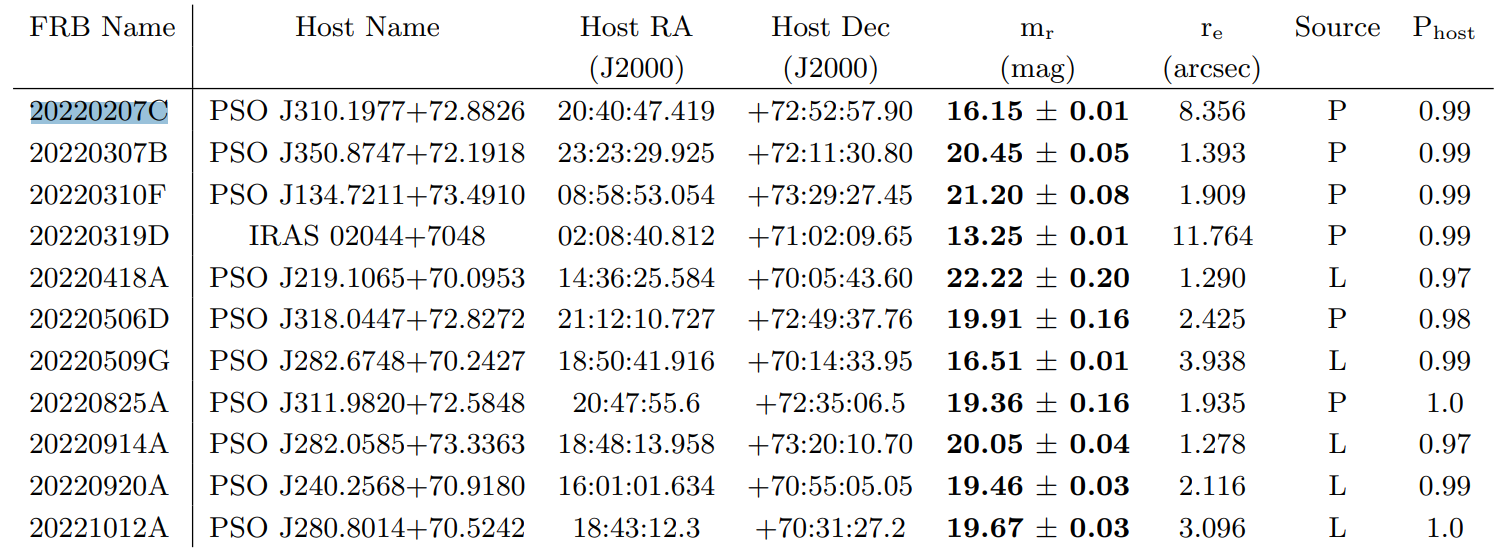

20220207C
PS1 Kron mag r 18.239099502563477
PS1 PSF mag r 20.379899978637695
PS1 Kron mag g-r 1.5564002990722656
PS1 PSF mag g-r 1.1895999908447266
20220307B
PS1 Kron mag r 19.93269920349121
PS1 PSF mag r 20.667499542236328
PS1 Kron mag g-r 1.2042007446289062
PS1 PSF mag g-r 1.1034011840820312
20220310F
PS1 Kron mag r 20.718700408935547
PS1 PSF mag r 21.593299865722656
PS1 Kron mag g-r 1.5662002563476562
PS1 PSF mag g-r 0.9894008636474609
20220319D
PS1 Kron mag r 15.387200355529785
PS1 PSF mag r 17.92300033569336
PS1 Kron mag g-r 2.0640993118286133
PS1 PSF mag g-r 1.1791000366210938
20220418A
PS1 Kron mag r -999.0
PS1 PSF mag r -999.0
PS1 Kron mag g-r 1021.5869007110596
PS1 PSF mag g-r 1021.8997993469238
20220506D
PS1 Kron mag r 21.456499099731445
PS1 PSF mag r 22.129499435424805
PS1 Kron mag g-r -1020.4564990997314
PS1 PSF mag g-r 2.473501205444336
20220509G
PS1 Kron mag r 17.730100631713867
PS1 PSF mag r 18.606800079345703
PS1 Kron mag g-r 0.8834991455078125
PS1 PSF mag g-r 0.8418006

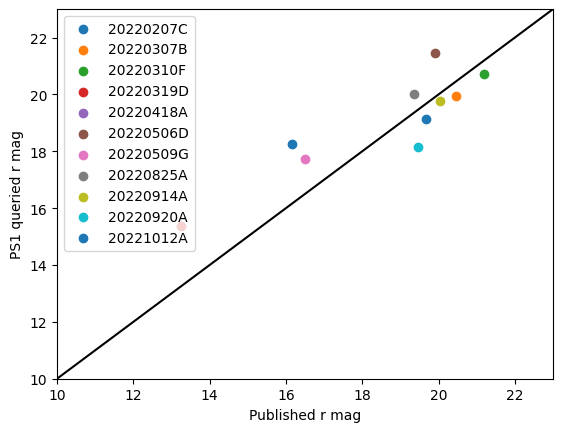

In [44]:
plt.figure()
rmag_query = []
for name, coord,rmag_pub in [
    ['20220207C', SkyCoord(ra = '20h40m47.419s', dec = '+72d52m57.90s'), 16.15],
    ['20220307B', SkyCoord(ra = '23h23m29.925s', dec = '+72d11m30.80s'),20.45],
    ['20220310F', SkyCoord(ra = '08h58m53.054s', dec = '+73d29m27.45s'), 21.20],
    ['20220319D', SkyCoord(ra = '02h08m40.812s', dec = '+71d02m09.65s'),13.25],
    ['20220418A', SkyCoord(ra = '14h36m25.584s', dec = '+70d05m43.60s'),22.22],
    ['20220506D', SkyCoord(ra = '21h12m10.727s', dec = '+72d49m37.76s'),19.91],
    ['20220509G', SkyCoord(ra = '18h50m41.916s', dec = '+70d14m33.95s'),16.51],
    ['20220825A', SkyCoord(ra = '20h47m55.6s', dec = '+72d35m06.5s'),19.36],
    ['20220914A', SkyCoord(ra = '18h48m13.958s', dec = '+73d20m10.70s'),20.05],
    ['20220920A', SkyCoord(ra = '16h01m01.634s', dec = '+70d55m05.05s'),19.46],
    ['20221012A', SkyCoord(ra = '18h43m12.3s', dec = '+70d31m27.2s'),19.67],
]:
        surv = panstarrs.Pan_STARRS_Survey(coord = coord, radius = 10/3600 * u.deg)
        catalog = surv.get_catalog()
        print(name)
        print('PS1 Kron mag r', catalog['Pan-STARRS_r'][0])
        print('PS1 PSF mag r', catalog['rPSFmag'][0])
        print('PS1 Kron mag g-r',catalog['Pan-STARRS_g'][0] - catalog['Pan-STARRS_r'][0])
        print('PS1 PSF mag g-r',catalog['gPSFmag'][0] - catalog['rPSFmag'][0])
        plt.scatter(rmag_pub, catalog['Pan-STARRS_r'][0],label = name)
        rmag_query.append(catalog['Pan-STARRS_r'][0])
plt.legend()
plt.ylim(10,23)
plt.xlim(10,23)
plt.xlabel('Published r mag')
plt.ylabel('PS1 queried r mag')
plt.plot([10,23],[10,23],color = 'black')

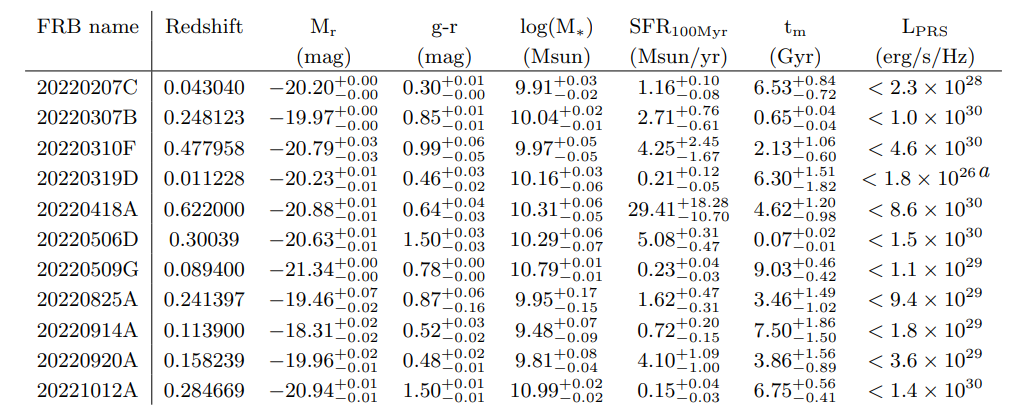

In [73]:
haspath = (type(final['primary_id']) is str)

In [83]:
all_psids = [str(s) for s in final['primary_id'] if str(s)[0] == 'P'] + [str(s) for s in final['secondary_id'] if str(s)[0] == 'P']

In [88]:
','.join([a[11:] for a in all_psids])

'201713557741821895,171220360141353770,150120264676039997,147880719743595797,215110220483728025,151973467535638727,166460786900208765,113360826227259720,140420596664782839,173383437614223218,153483123862476859,154360650307570235,140170545876545920,158090182417819186,170170111139029291,213571320663815844,209893045145819992,147790546649113381,215062842517036820,148733303360097347,178690368364970411,195463075298975481,209731095953009613'

# PS1 STRM

# PS1 STRM WISE

In [10]:
from astropy.coordinates import SkyCoord
from frb.surveys import panstarrs
from astropy import units as u

In [19]:
from astropy.cosmology import Planck18

In [30]:
coord.galactic.l, coord.galactic.b # away from galactic center (l = 0, b = 0)? Double check

(<Longitude 106.93853472 deg>, <Latitude 18.39030313 deg>)

In [43]:
name, coord, = '20220509G', SkyCoord(ra = '18h50m41.916s', dec = '+70d14m33.95s')#,16.51
surv = panstarrs.Pan_STARRS_Survey(coord = coord, radius = 10/3600 * u.deg)
catalog = surv.get_catalog()
print(name)
print('PS1 Kron mag r', catalog['Pan-STARRS_r'][0])
print('PS1 PSF mag r', catalog['rPSFmag'][0])
print('PS1 Kron mag g-r',catalog['Pan-STARRS_g'][0] - catalog['Pan-STARRS_r'][0])
print('PS1 PSF mag g-r',catalog['gPSFmag'][0] - catalog['rPSFmag'][0])
catalog



20220509G
PS1 Kron mag r 17.730100631713867
PS1 PSF mag r 18.606800079345703
PS1 Kron mag g-r 0.8834991455078125
PS1 PSF mag g-r 0.8418006896972656


Pan-STARRS_ID,ra,dec,objInfoFlag,qualityFlag,rKronRad,gPSFmag,rPSFmag,iPSFmag,zPSFmag,yPSFmag,gPSFmagErr,rPSFmagErr,iPSFmagErr,zPSFmagErr,yPSFmagErr,Pan-STARRS_g,Pan-STARRS_r,Pan-STARRS_i,Pan-STARRS_z,Pan-STARRS_y,Pan-STARRS_g_err,Pan-STARRS_r_err,Pan-STARRS_i_err,Pan-STARRS_z_err,Pan-STARRS_y_err,separation
,,,,,,,,,,,,,,,,,,,,,,,,,,arcmin
int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
192292826747602048,282.67479903,70.24273596,528801792,63,5.167119979858398,19.44860076904297,18.606800079345703,18.230499267578125,18.059499740600586,17.815099716186523,0.007571000140160322,0.005200999788939953,0.0021689999848604202,0.004594999831169844,0.012687000446021557,18.61359977722168,17.730100631713867,16.584400177001953,16.388200759887695,16.802600860595703,0.009176000021398067,0.006182999815791845,0.002194999950006604,0.004461999982595444,0.013512999750673771,0.003456079683545766
192292826721342679,282.67207108,70.24326876,520413312,62,5.321000099182129,17.75510025024414,17.223400115966797,17.08169937133789,17.020599365234375,16.94860076904297,0.0025629999581724405,0.0019020000472664833,0.0010010000551119447,0.002283999929204583,0.0057830000296235085,17.433900833129883,17.001800537109375,17.125200271606445,17.061500549316406,16.644899368286133,0.003321999916806817,0.0031679999083280563,0.00139999995008111,0.0034000000450760126,0.010854000225663185,0.06044395966572877


In [34]:
catalog

Pan-STARRS_ID,ra,dec,objInfoFlag,qualityFlag,rKronRad,gPSFmag,rPSFmag,iPSFmag,zPSFmag,yPSFmag,gPSFmagErr,rPSFmagErr,iPSFmagErr,zPSFmagErr,yPSFmagErr,Pan-STARRS_g,Pan-STARRS_r,Pan-STARRS_i,Pan-STARRS_z,Pan-STARRS_y,Pan-STARRS_g_err,Pan-STARRS_r_err,Pan-STARRS_i_err,Pan-STARRS_z_err,Pan-STARRS_y_err,separation
,,,,,,,,,,,,,,,,,,,,,,,,,,arcmin
int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
195453101976309735,310.19779658,72.88258754,512024576,61,7.464320182800293,21.569499969482422,20.379899978637695,19.726699829101562,19.22089958190918,18.78380012512207,0.04682900011539459,0.01797500066459179,0.011630999855697155,0.01714400015771389,0.02572599984705448,19.795499801635742,18.239099502563477,17.4552001953125,17.032499313354492,16.74049949645996,0.02523599937558174,0.010761000216007233,0.00774300005286932,0.011157999746501446,0.01627100072801113,0.010476508204587778
195463101911721908,310.19116087,72.88428268,436527104,52,2.1419100761413574,23.484800338745117,21.85810089111328,20.094100952148438,19.13159942626953,18.771400451660156,0.2820650041103363,0.07609999924898148,0.015951000154018402,0.01537100039422512,0.02455800026655197,-999.0,22.012699127197266,20.268199920654297,19.372299194335938,18.93280029296875,-999.0,0.11025899648666382,0.025831999257206917,0.02504199929535389,0.03811100125312805,0.14595472898357603


In [37]:
import matplotlib.pyplot as plt

In [13]:
from astropy.coordinates import SkyCoord
from astropy import units as u

In [28]:
names = 
[
'20220207C',
'20220307B',
'20220310F',
'20220319D',
'20220418A',
'20220506D',
'20220509G',
'20220825A',
'20220914A',
'20220920A',
'20221012A'
]

hg =[
    SkyCoord(ra = 310.1977, dec = 72.8826,unit = 'deg'),
    SkyCoord(ra = 350.8747, dec = 72.1918,unit = 'deg'),
    SkyCoord(ra = 134.7211, dec = 73.4910,unit = 'deg'),
    SkyCoord(ra = '02h08m40.8598703712s',dec = '71d02m09.146975892s'),
    SkyCoord(ra = 219.1065, dec = 70.0953,unit = 'deg'),
    SkyCoord(ra = 318.0447, dec = 72.8272,unit = 'deg'),
    SkyCoord(ra = 282.6748, dec = 70.2427,unit = 'deg'),
    SkyCoord(ra = 311.9820, dec = 72.5848,unit = 'deg'),
    SkyCoord(ra = 282.0585, dec = 73.3363,unit = 'deg'),
    SkyCoord(ra = 240.2568, dec = 70.9180,unit = 'deg'),
    SkyCoord(ra = 280.8014, dec = 70.5242,unit = 'deg')
]
for n,h in zip(names,hg):
    surv = panstarrs.Pan_STARRS_Survey(coord = h, radius = 2/3600 * u.deg)
    catalog = surv.get_catalog()
    print(catalog)
    print(n,catalog[-1]['Pan-STARRS_g'], catalog[-1]['Pan-STARRS_r'],catalog[-1]['Pan-STARRS_z'])

20220207C 19.795499801635742 18.239099502563477 17.032499313354492
20220307B 21.136899948120117 19.93269920349121 18.94070053100586
20220310F 22.284900665283203 20.718700408935547 20.96940040588379
20220319D 17.4512996673584 15.387200355529785 15.48449993133545
20220418A 22.58690071105957 -999.0 20.691499710083008
20220506D -999.0 21.456499099731445 -999.0
20220509G 18.61359977722168 17.730100631713867 16.388200759887695
20220825A 20.811399459838867 20.026500701904297 19.237699508666992
20220914A 20.499000549316406 19.768299102783203 19.351999282836914
20220920A 18.617399215698242 18.15690040588379 17.703699111938477
20221012A 20.465900421142578 19.14069938659668 18.33679962158203


In [18]:
catalog

Pan-STARRS_ID,ra,dec,objInfoFlag,qualityFlag,rKronRad,gPSFmag,rPSFmag,iPSFmag,zPSFmag,yPSFmag,gPSFmagErr,rPSFmagErr,iPSFmagErr,zPSFmagErr,yPSFmagErr,Pan-STARRS_g,Pan-STARRS_r,Pan-STARRS_i,Pan-STARRS_z,Pan-STARRS_y,Pan-STARRS_g_err,Pan-STARRS_r_err,Pan-STARRS_i_err,Pan-STARRS_z_err,Pan-STARRS_y_err,separation
,,,,,,,,,,,,,,,,,,,,,,,,,,arcmin
int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
192622808012709788,280.8013915,70.52419478,512024576,61,3.8939900398254395,21.20639991760254,19.85099983215332,19.26180076599121,19.03030014038086,18.669700622558594,0.030067000538110733,0.01133000012487173,0.006105000153183937,0.011850999668240547,0.026249000802636147,20.465900421142578,19.14069938659668,18.583200454711914,18.33679962158203,18.178699493408203,0.03146800026297569,0.013876000419259071,0.008334999904036522,0.014860999770462513,0.031252000480890274,0.00035638085611327023


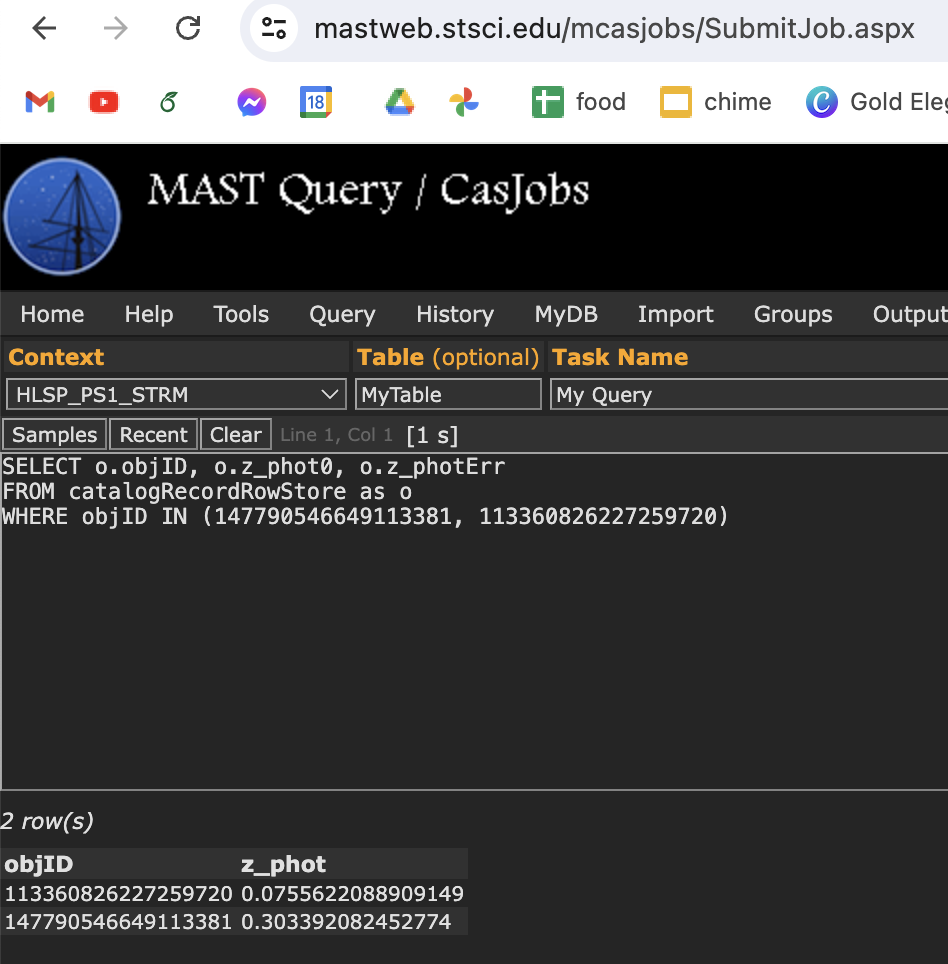 
This also works